In [2]:
import pandas as pd
from datetime import datetime
import numpy as np
from numpy import random as npr
import matplotlib.pyplot as plt 

Specify model constants per full-time equivalent (fte)

In [3]:
daily_rate = 400
technology_charges = 500
overhead_charges = 200

Specify model risk factors that have little or no correlation among them.

In [ ]:
# Number of trials/simulations
n = 10000  

# Number of full-time equivalent persons on the team
num_ftes = npr.uniform(low=1, high=5, size=n)  

# In person days and driven independently by the scope of the project
effort = npr.uniform(low=240, high=480, size=n)

# Based on market research or expert judgment or both
price = npr.uniform(low=100, high=200, size=n)

# Independent of price in the price range considered
units = npr.normal(loc=1000, scale=500, size=n)

Specify how risk factors affect the project model

In [ ]:
labor_costs = effort * daily_rate
technology_costs = num_ftes * technology_charges
overhead_costs = num_ftes * overhead_charges
revenues = price * units

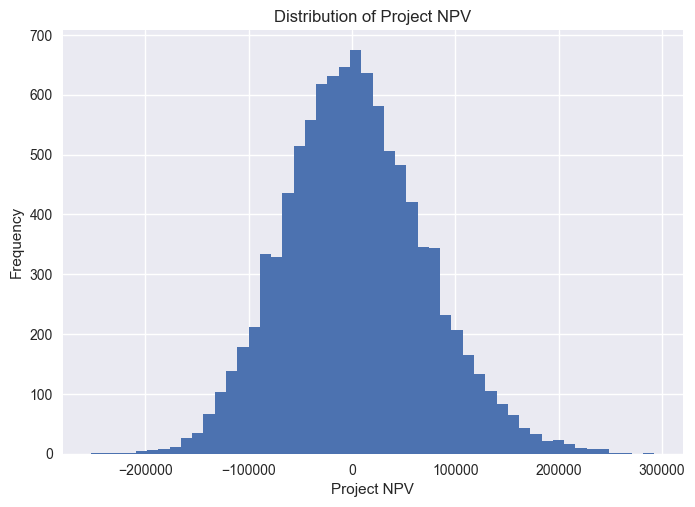

            NPV
count   10000.0
mean     3382.0
std     68634.0
min   -252698.0
25%    -43460.0
50%       111.0
75%     47252.0
max    292485.0
There is a 50.16% probability that the project will have a positive NPV.


In [6]:
# Specify other constants
tax_rate = 0.15

# Specify target_value
free_cash_flow = (revenues - labor_costs - technology_costs - overhead_costs)  * (1 - tax_rate)

# Simulate project NPV assuming initial FCF=0
# Discount rate for the project period based on risk of similar efforts 
discount_rate = npr.uniform(low=0.06, high=0.10, size=n)
npv = free_cash_flow/(1 + discount_rate)

# Convert numpy array to pandas DataFrame for easier analysis
NPV = pd.DataFrame(npv, columns=['NPV'])

# Plot histogram of NPV distribution
plt.hist(NPV['NPV'], bins=50)
plt.title ('Distribution of Project NPV')
plt.xlabel('Project NPV') 
plt.ylabel('Frequency')
plt.show()
print(NPV.describe().round())
success_probability = sum(NPV['NPV'] > 0)/n *100
print(f'There is a {success_probability:.2f}% probability that the project will have a positive NPV.')

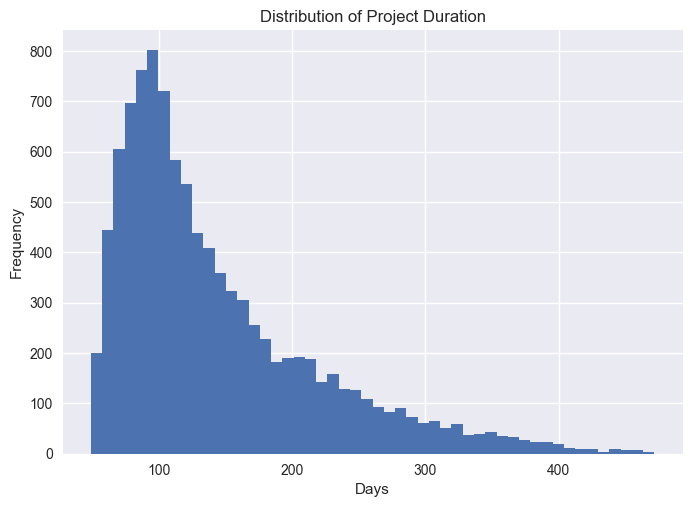

          Days
count  10000.0
mean     144.0
std       76.0
min       49.0
25%       89.0
50%      119.0
75%      178.0
max      472.0


In [ ]:
# Estimate project duration in days
# Duration determines the number of days the project will take to complete
# assuming no interruption. Different from the elapsed time of the project.
duration = effort / num_ftes
Duration = pd.DataFrame(duration, columns=['Days'])

# Plot histogram of project duration distribution
plt.hist(Duration['Days'], bins=50)
plt.title ('Distribution of Project Duration')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()
print(Duration.describe().round())